In [ ]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print(f'Train: {X_train.shape[0]} samples')
print(f'Number of trees   : {rf_model.n_estimators}')
print(f'Number of features: {rf_model.n_features_in_}')

Train: 736 samples
Number of trees   : 100
Number of features: 23


In [19]:
# Training vs Test Performance

y_train_pred = rf_model.predict(X_train)
y_test_pred  = rf_model.predict(X_test)

metrics = {
    'Set'       : ['Train', 'Test'],
    'Accuracy'  : [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    'F1 Score'  : [f1_score(y_train, y_train_pred),       f1_score(y_test, y_test_pred)],
    'Precision' : [precision_score(y_train, y_train_pred), precision_score(y_test, y_test_pred)],
    'Recall'    : [recall_score(y_train, y_train_pred),   recall_score(y_test, y_test_pred)]
}

metrics_df = pd.DataFrame(metrics).set_index('Set')
print(' Train vs Test Metrics ')
print(metrics_df.round(4).to_string())

 Train vs Test Metrics 
       Accuracy  F1 Score  Precision  Recall
Set                                         
Train    1.0000     1.000      1.000   1.000
Test     0.8533     0.872      0.844   0.902


In [20]:
# Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')
cv_f1       = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='f1')

print(' 5-Fold Cross-Validation Results ')
print(f'Accuracy per fold : {cv_accuracy.round(4)}')
print(f'Mean Accuracy     : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}')
print(f'\nF1 per fold       : {cv_f1.round(4)}')
print(f'Mean F1 Score     : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

 5-Fold Cross-Validation Results 
Accuracy per fold : [0.8041 0.8095 0.8095 0.8231 0.8435]
Mean Accuracy     : 0.8180 +/- 0.0143

F1 per fold       : [0.8343 0.8391 0.825  0.8395 0.8553]
Mean F1 Score     : 0.8386 +/- 0.0098


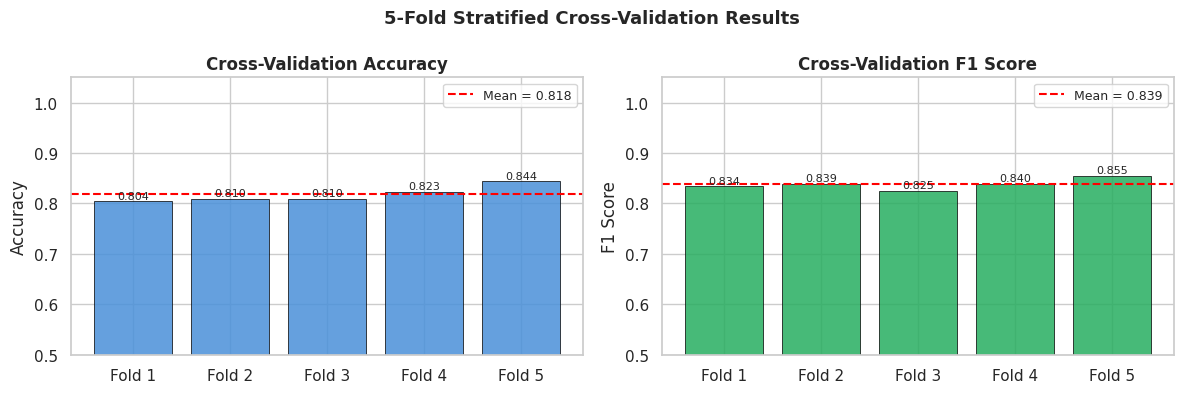

In [21]:
# CV Results Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
folds = [f'Fold {i+1}' for i in range(5)]

for ax, scores, label, color in zip(
    axes,
    [cv_accuracy, cv_f1],
    ['Accuracy', 'F1 Score'],
    ['#4A90D9', '#27AE60']
):
    bars = ax.bar(folds, scores, color=color, edgecolor='black', linewidth=0.6, alpha=0.85)
    ax.axhline(scores.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean = {scores.mean():.3f}')
    ax.set_ylim(0.5, 1.05)
    ax.set_title(f'Cross-Validation {label}', fontweight='bold')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8)

fig.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('m3_cv_results.png', dpi=150)
plt.show()

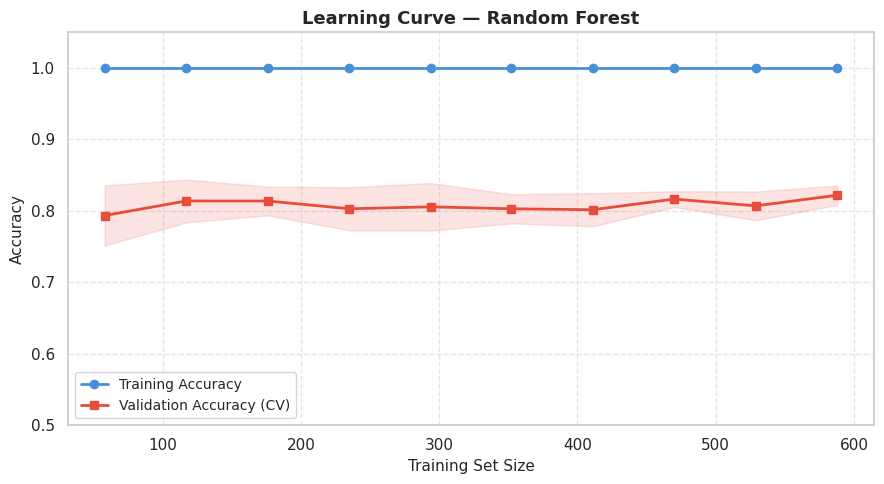

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=cv,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4A90D9', label='Training Accuracy', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4A90D9')
ax.plot(train_sizes, val_mean, 's-', color='#E74C3C', label='Validation Accuracy (CV)', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#E74C3C')

ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve — Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_learning_curve.png', dpi=150)
plt.show()

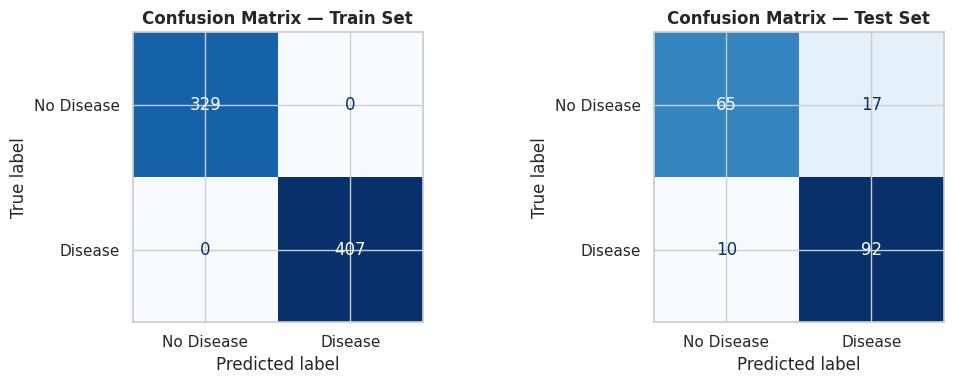

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_train_pred, y_test_pred],
    ['Confusion Matrix — Train Set', 'Confusion Matrix — Test Set']
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Disease', 'Disease']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('m3_confusion_matrix.png', dpi=150)
plt.show()

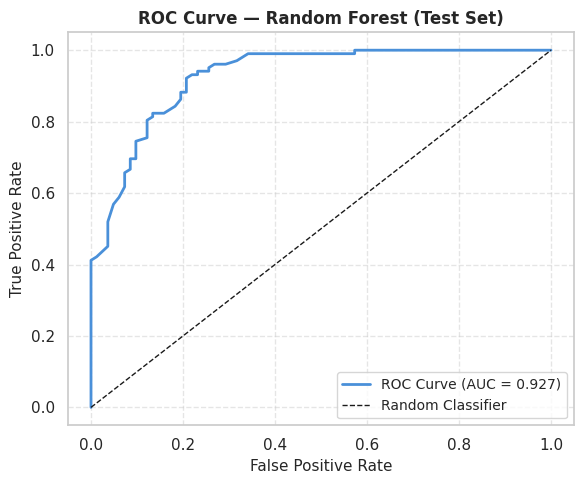

In [24]:
y_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#4A90D9', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Random Forest (Test Set)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_roc_curve.png', dpi=150)
plt.show()

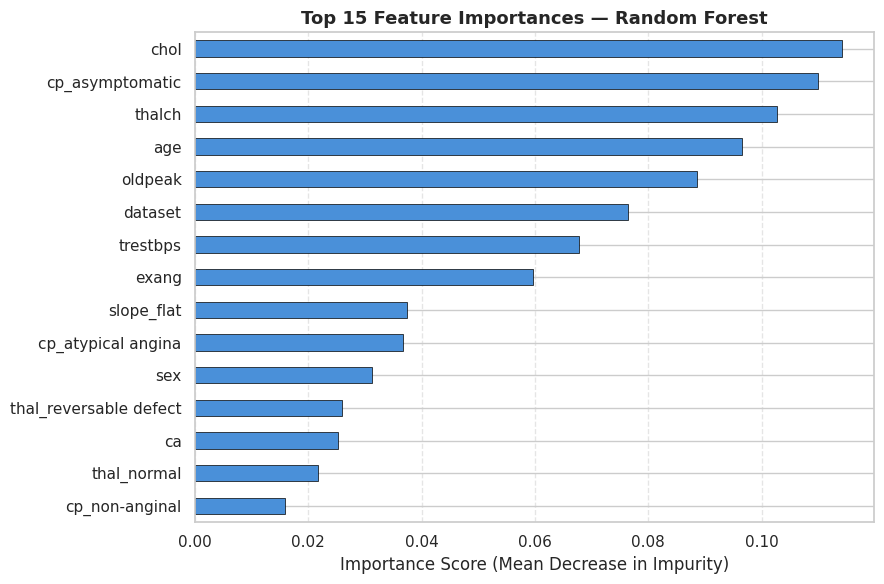

In [25]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

top15 = importances[-15:]

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#4A90D9', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m3_feature_importance.png', dpi=150)
plt.show()

In [26]:
print('── Classification Report (Test Set) ──')
print(classification_report(y_test, y_test_pred,
                             target_names=['No Disease', 'Disease']))

print('── Final Summary ──')
print(f'Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Test F1 Score : {f1_score(y_test, y_test_pred):.4f}')
print(f'ROC AUC Score : {auc_score:.4f}')
print(f'CV Mean Acc   : {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}')
print('\nMilestone 3 complete.')

── Classification Report (Test Set) ──
              precision    recall  f1-score   support

  No Disease       0.87      0.79      0.83        82
     Disease       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184

── Final Summary ──
Test Accuracy : 0.8533
Test F1 Score : 0.8720
ROC AUC Score : 0.9275
CV Mean Acc   : 0.8180 +/- 0.0143

Milestone 3 complete.
